# LangGraph: A Detailed Overview

As Large Language Models (LLMs) continue to evolve, AI applications are becoming more than simple chatbots. Modern AI systems need to reason, make decisions, interact with external tools, maintain memory, and execute complex workflows. **LangGraph** is an open-source framework from the LangChain ecosystem that enables developers to build these advanced, stateful AI agents with ease.

Unlike traditional AI pipelines that execute tasks sequentially, LangGraph represents an application as a **graph**. Each node in the graph performs a specific task—such as calling an LLM, retrieving documents, executing a tool, or validating outputs—while edges determine how execution flows between nodes. This graph-based architecture allows workflows to branch, loop, retry failed operations, pause for human approval, or terminate dynamically based on runtime conditions.

## Core Concepts

### State Management

LangGraph revolves around a shared **State** object that stores conversation history, intermediate results, tool outputs, user inputs, and other contextual information. Every node can read from and update this state, enabling seamless communication across the workflow.

### Nodes

Nodes are the individual building blocks of a workflow. A node can perform various operations, including:

- Invoking an LLM
- Executing custom Python functions
- Calling external APIs
- Querying databases
- Retrieving documents for RAG
- Validating responses

Each node receives the current state, processes it, and returns updates.

### Edges

Edges define how execution moves from one node to another.

LangGraph supports:

- Linear execution
- Conditional routing
- Loops
- Dynamic branching

This flexibility enables intelligent decision-making within workflows.

### START and END

Every graph begins at a predefined `START` node and finishes at an `END` node, making workflows structured and predictable.

---

# Key Features

## Persistent Memory

LangGraph supports checkpointing through multiple storage backends, including:

- SQLite
- PostgreSQL
- Redis
- Custom storage providers

This enables long-running conversations and workflows that can resume even after interruptions.

## Human-in-the-Loop

Applications can pause execution before performing sensitive operations such as:

- Sending emails
- Processing payments
- Updating databases
- Executing production actions

A human reviewer can approve or reject the action before execution continues.

## Tool Calling

LangGraph integrates directly with LangChain tools, making it easy to connect AI agents to:

- REST APIs
- Databases
- File systems
- Search engines
- Python functions
- Third-party services

This allows agents to perform real-world actions rather than simply generating text.

## Multi-Agent Architecture

LangGraph enables multiple specialized agents to collaborate.

Examples include:

- Planner Agent
- Research Agent
- Coding Agent
- Reviewer Agent
- Validation Agent

Each agent can perform a dedicated responsibility while sharing a common workflow state.

## Streaming Support

Applications can stream:

- Model tokens
- Intermediate events
- Tool execution updates
- State changes

This improves responsiveness for interactive applications.

## Fault Tolerance

LangGraph supports:

- Retry mechanisms
- Error recovery
- Conditional fallbacks
- Workflow resumption

These capabilities improve reliability in production environments.

---

# Common Use Cases

LangGraph is suitable for a wide variety of AI applications, including:

- AI customer support platforms
- Autonomous coding assistants
- Retrieval-Augmented Generation (RAG) systems
- Workflow automation
- Email and calendar assistants
- Document intelligence platforms
- Multi-agent research systems
- Enterprise process automation

---

# Why LangGraph?

Traditional LangChain chains are ideal for simple, sequential workflows but become increasingly difficult to maintain when applications require memory, branching, retries, or multiple collaborating agents.

LangGraph addresses these limitations by providing:

- Stateful execution
- Graph-based workflow orchestration
- Persistent memory
- Human approval workflows
- Multi-agent collaboration
- Robust error handling

It integrates seamlessly with the broader LangChain ecosystem, including models from OpenAI, Anthropic, Google Gemini, Groq, Ollama, Hugging Face, and numerous vector databases and retrieval systems.

---

# Conclusion

LangGraph has become one of the most powerful frameworks for building production-ready AI agents. By combining **state management, graph-based orchestration, persistent memory, human-in-the-loop capabilities, tool integration, and multi-agent coordination**, it enables developers to build intelligent systems that go far beyond traditional chatbot interactions.

Whether you're developing a conversational assistant, an autonomous software engineering agent, a document processing pipeline, or an enterprise automation platform, LangGraph provides the flexibility, scalability, and reliability required to create sophisticated AI applications for real-world use.

### Build basic Chatboot using LangGraph

In [17]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START, END
from langgraph.graph.message import add_messages

In [18]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)
graph_builder

In [19]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
# from services.model import openai_model


load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
# model = ChatOpenAI(
#     model="gpt-4.1",
#     max_tokens=None,
#     timeout=None,
#     max_retries=2,
#     # api_key="...",
#     # base_url="...",
#     # organization="...",
#     # other params...
# )

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.0,
    max_retries=2,
    # other params...
)


In [20]:
def chatbot(state:State):
    return{"messages":[model.invoke(state["messages"])]}

In [21]:
graph_builder= StateGraph(State)
graph_builder.add_node('chat',chatbot)
graph_builder.add_edge(START, 'chat')
graph_builder.add_edge('chat', END)
graph=graph_builder.compile()

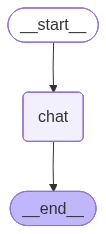

In [22]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error occurred: {e}")

In [23]:
res = graph.invoke({"messages": [{"role": "user", "content": "Give me an using easydev.in what si this website saying"}]})
print(res["messages"][-1].content)
print(res["messages"][-1].usage_metadata)

Easydev.in appears to be a website that provides information and resources on web development, programming, and technology. The website seems to offer a range of services, including:

1. **Tutorials and Guides**: Easydev.in provides step-by-step tutorials, guides, and articles on various programming topics, such as web development, mobile app development, and data science.
2. **Coding Examples**: The website offers coding examples, snippets, and demos to help developers learn and implement various programming concepts.
3. **Project Ideas**: Easydev.in provides project ideas and suggestions for developers to work on, which can help them gain practical experience and build their portfolios.
4. **Interview Preparation**: The website offers resources and materials to help developers prepare for technical interviews, including common interview questions, practice problems, and tips.
5. **News and Updates**: Easydev.in publishes news, updates, and trends in the tech industry, keeping develop

In [24]:
for event in graph.stream({"messages": [{"role": "user", "content": "Give me today's ai news"}]}):
    for value in event.values():
        print(value["messages"][-1].content)

As my knowledge cutoff is December 2023, I'll provide you with some recent AI news up to that point. Keep in mind that the field of AI is rapidly evolving, and there may be more recent developments.

Here are some notable AI news stories from 2023:

1. **ChatGPT and AI-powered chatbots**: OpenAI's ChatGPT, a conversational AI model, gained significant attention in 2023. It can understand and respond to human-like queries, sparking discussions about its potential applications and limitations.
2. **Google's Gemini AI model**: Google announced Gemini, a new AI model that can process and understand natural language, vision, and other forms of data. Gemini is designed to be a more general-purpose AI model, capable of handling a wide range of tasks.
3. **Meta's Llama AI model**: Meta released Llama, a large language model that can process and generate human-like text. Llama is designed to be a more efficient and scalable AI model, with potential applications in areas like customer service an

# Chatbot with Tool

Large Language Models (LLMs) are powerful at understanding and generating text, but they cannot directly access external systems, retrieve live information, or perform real-world actions on their own. A **chatbot with tools** extends an LLM by allowing it to invoke external functions, APIs, databases, or services whenever additional information or actions are required. This enables the chatbot to move beyond text generation and become an intelligent AI agent.

## How It Works

When a user submits a request, the LLM first analyzes the query to determine whether it can answer using its internal knowledge or if it needs assistance from an external tool. If a tool is required, the model generates a structured tool call containing the necessary parameters. The selected tool executes the requested operation, returns the result to the LLM, and the model incorporates that information into its final response.

This entire process is orchestrated automatically, making tool usage seamless from the user's perspective.

## Common Tools

A chatbot can integrate with various tools, including:

- Web search for live information
- Weather APIs
- Database queries
- Email services
- Calendar management
- File processing
- SQL databases
- Vector databases for RAG
- Custom business APIs

## Benefits

- Access to real-time information
- Ability to perform external actions
- Reduced hallucinations by retrieving accurate data
- Integration with enterprise systems
- Automation of repetitive business tasks
- Improved accuracy through external verification

## Tool Calling in LangGraph

LangGraph provides built-in support for tool calling through **LangChain Tools** and the **ToolNode**. During execution, the LLM determines when a tool is needed, the workflow routes the request to the appropriate tool, receives the output, and returns control to the model to generate the final response. This graph-based execution makes it easy to combine multiple tools with memory, conditional routing, and human approval.

## Common Use Cases

- AI customer support
- Travel assistants
- Coding assistants
- Email automation
- Document search (RAG)
- Database querying
- Business workflow automation
- Personal productivity assistants

## Conclusion

A chatbot with tools transforms a traditional conversational AI into an intelligent assistant capable of interacting with the outside world. By combining an LLM's reasoning ability with external tools, developers can build applications that retrieve live information, automate tasks, execute business workflows, and provide more accurate, reliable, and actionable responses.

#### Uisng langchain-tavily	

In [25]:
from langchain_tavily import TavilySearch
search_tool =TavilySearch(max_results=2)
search_tool.invoke("What is langraph?")

{'query': 'What is langraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [26]:
## Custom Functions

def multiply(a:int, b:int)->int:
    """Multiplies two integers.
    Args:
        a (int): The first integer.
        b (int): The second integer.
    Returns:
        int: The product of the two integers.
    """
    return a * b

In [27]:
def calculator(x, y, operation):
    """"this is a simple calculator function 
    arguments:
    x (float): first number
    y (float): second number
    operation (str): the operation to perform
    """
    if operation == "add":
        return x + y
    elif operation == "subtract":
        return x - y
    elif operation == "multiply":
        return x * y
    elif operation == "divide":
        return x / y

In [28]:
tools=[search_tool     ,multiply]

In [29]:
llm_with_tool=model.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E63542B390>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E63542BD90>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'descr

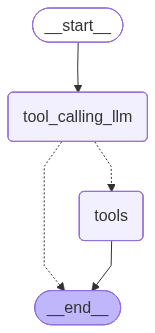

In [30]:
##StateGraph




from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition



## Node defination

def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

##Graph
builder =StateGraph(State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',ToolNode(tools))
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    #if the latest message from assistant then call->tools conditon route
    tools_condition,
    
)
builder.add_edge('tools', END)

graph =builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
result = graph.invoke({"messages": [{"role": "user", "content": "What is current News?"}]})
print(result["messages"][-1].content)

{"query": "current news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newser.com/story/392645/japan-launches-first-test-flight-of-its-reusable-rocket.html", "title": "Big First for Japan in Race to Compete With SpaceX - Newser", "score": 0.70580584, "published_date": "Sat, 11 Jul 2026 16:30:00 GMT", "content": "Image 1: Newser - Current News - Breaking StoriesImage 2: Newser - Current News - Breaking Stories. Image 8: Newser - Current News - Breaking Stories. Japan's experimental reusable rocket took off and safely landed in a first test flight on Saturday as the country seeks to achieve the technology key to cutting launch costs and competing in the global space market dominated by SpaceX. The RV-X rocket lifted off, hovered, and moved horizontally before landing during its less than one-minute flight at the Japan Aerospace Exploration Agency's Noshiro Rocket Testing Center in northeastern Japan, which was livestreamed by the NVS, a grou

In [32]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is current News?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (9n4mfhxwz)
 Call ID: 9n4mfhxwz
  Args:
    query: current news
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "current news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newser.com/story/392645/japan-launches-first-test-flight-of-its-reusable-rocket.html", "title": "Big First for Japan in Race to Compete With SpaceX - Newser", "score": 0.70580584, "published_date": "Sat, 11 Jul 2026 16:30:00 GMT", "content": "Image 1: Newser - Current News - Breaking StoriesImage 2: Newser - Current News - Breaking Stories. Image 8: Newser - Current News - Breaking Stories. Japan's experimental reusable rocket took off and safely landed in a 

In [33]:
result = graph.invoke({"messages": [{"role": "user", "content": " give me current news then What is 44 Multiply by 2 and then add 10 with it then  again multiple by 2? and who is easydev"}]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

 give me current news then What is 44 Multiply by 2 and then add 10 with it then  again multiple by 2? and who is easydev
================================== Ai Message ==================================
Tool Calls:
  tavily_search (82p42h9sa)
 Call ID: 82p42h9sa
  Args:
    query: current news
    search_depth: basic
    topic: news
  multiply (0xxeffkrv)
 Call ID: 0xxeffkrv
  Args:
    a: 44
    b: 2
  multiply (e4dqvr3q9)
 Call ID: e4dqvr3q9
  Args:
    a: 94
    b: 2
  tavily_search (vw57s6ckc)
 Call ID: vw57s6ckc
  Args:
    query: easydev
    search_depth: basic
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "current news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newser.com/story/392645/japan-launches-first-test-flight-of-its-reusable-rocket.html", "title": "Big Firs

# ReAct Agent Architecture

The **ReAct (Reason + Act)** architecture is an AI agent design pattern that combines **reasoning** and **tool execution** to solve complex tasks. Instead of generating a single response, the agent continuously **thinks**, **acts**, **observes**, and **reasons** until it reaches the final answer. This approach enables Large Language Models (LLMs) to interact with external tools, APIs, databases, search engines, and custom functions while maintaining logical decision-making throughout the workflow.

## How ReAct Works

A ReAct agent follows an iterative execution loop:

1. **Thought (Reasoning):** The LLM analyzes the user's request and determines the next step.
2. **Action:** If additional information or computation is needed, the agent invokes an appropriate tool.
3. **Observation:** The tool returns its result, which is added to the conversation state.
4. **Reasoning:** The LLM evaluates the observation and decides whether another tool call is required or if it has enough information to answer.
5. **Final Answer:** Once the objective is achieved, the agent generates a response for the user.

This cycle continues until the task is complete.

```text
User Input
     │
     ▼
┌─────────────────────┐
│      LLM Thinks     │
│ (Reason / Planning) │
└──────────┬──────────┘
           │
           ▼
 Is a Tool Required?
      │         │
     Yes        No
      │         │
      ▼         ▼
┌──────────────┐ Final Response
│ Execute Tool │
└──────┬───────┘
       │
       ▼
 Receive Observation
       │
       ▼
 Back to LLM Reasoning
```

## Core Components

- **LLM:** Performs reasoning and decides when to use tools.
- **Tools:** External functions, APIs, databases, web search, calculators, or custom business logic.
- **Memory:** Stores conversation history, tool outputs, and intermediate reasoning.
- **Agent Executor:** Manages the reasoning-action loop until completion.

## Advantages

- Dynamic decision-making
- Real-time information retrieval
- Reduced hallucinations through external verification
- Multi-step problem solving
- Integration with enterprise systems and APIs
- Improved reasoning using observations from tool outputs

## Common Use Cases

- AI customer support
- Coding assistants
- Web search agents
- Database query assistants
- Email and calendar automation
- Research assistants
- Financial analysis
- Enterprise workflow automation

## ReAct in LangGraph

LangGraph naturally implements the ReAct pattern using graph-based workflows. The LLM node performs reasoning, conditional edges determine whether a tool should be executed, the **ToolNode** invokes the selected tool, and the result is returned to the LLM for further reasoning. This loop continues until no additional tool calls are required, after which the workflow reaches the `END` node.

## Conclusion

The ReAct architecture is one of the most widely adopted patterns for building intelligent AI agents because it combines **reasoning** with **action**. By allowing LLMs to think, use external tools, observe results, and refine their decisions, ReAct enables reliable, scalable, and production-ready AI systems capable of solving complex real-world problems.

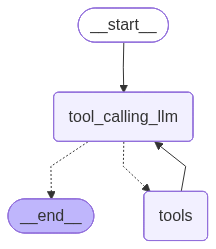

In [34]:
##StateGraph

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition


## Node defination

def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

##Graph
builder =StateGraph(State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',ToolNode(tools))
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    #if the latest message from assistant then call->tools conditon route
    tools_condition,
    
)
builder.add_edge('tools', "tool_calling_llm")

graph =builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
result = graph.invoke({"messages": [{"role": "user", "content": " give me current news then What is 44 Multiply by 2 and  again multiple by 9? and who is easydev"}]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

 give me current news then What is 44 Multiply by 2 and  again multiple by 9? and who is easydev
================================== Ai Message ==================================
Tool Calls:
  tavily_search (rtdggp773)
 Call ID: rtdggp773
  Args:
    query: current news
    search_depth: basic
    topic: news
  multiply (6nfp3sxz1)
 Call ID: 6nfp3sxz1
  Args:
    a: 44
    b: 2
  multiply (aqvtwxjv5)
 Call ID: aqvtwxjv5
  Args:
    a: 88
    b: 9
  tavily_search (cvc8hyvhe)
 Call ID: cvc8hyvhe
  Args:
    query: easydev
    search_depth: basic
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "current news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newser.com/story/392645/japan-launches-first-test-flight-of-its-reusable-rocket.html", "title": "Big First for Japan in Race to Co

# Adding Memory in an Agentic Graph

Memory is one of the most important capabilities of an AI agent. Without memory, an agent treats every interaction as a completely new conversation. By adding memory, the agent can remember previous messages, tool outputs, user preferences, and intermediate reasoning, enabling more personalized, context-aware, and long-running workflows.

## Why Memory?

Memory enables an AI agent to:

- Maintain conversation context
- Remember previous user interactions
- Store tool execution results
- Resume interrupted workflows
- Personalize responses
- Reduce repeated reasoning and API calls

In LangGraph, memory is implemented through **checkpointers**, which automatically save and restore the graph's state between executions.

## Memory Architecture

```text
               User
                 │
                 ▼
          ┌─────────────┐
          │ Agent Graph │
          └──────┬──────┘
                 │
                 ▼
           Update State
                 │
        ┌────────┴────────┐
        ▼                 ▼
     LLM Node         Tool Node
        │                 │
        └────────┬────────┘
                 ▼
          Checkpointer
                 │
                 ▼
         Persistent Storage
      (MemorySaver / SQLite /
       PostgreSQL / Redis)
                 │
                 ▼
        Next Conversation
```

## Types of Memory

### Short-Term Memory

Stores information only for the current conversation.

Examples:

- Chat history
- Tool outputs
- Intermediate reasoning
- Current workflow state

### Long-Term Memory

Persists information across multiple conversations.

Examples:

- User preferences
- Personal profile
- Business knowledge
- Retrieved documents
- Semantic memories stored in vector databases

## Checkpointers in LangGraph

LangGraph provides several checkpoint implementations:

- **MemorySaver** – In-memory storage for development and testing.
- **SQLite Checkpointer** – Local persistent storage.
- **PostgreSQL Checkpointer** – Production-grade persistence.
- **Redis Checkpointer** – High-performance distributed memory.
- **Custom Checkpointer** – Integrate your own storage backend.

## How Memory Works

1. A user sends a request.
2. The graph loads the saved state using a unique `thread_id`.
3. The agent executes reasoning and tool calls.
4. Updated messages and state are automatically checkpointed.
5. Future requests with the same `thread_id` continue from the previous state.

## Benefits

- Persistent conversations
- Multi-session continuity
- Human-in-the-loop workflows
- Stateful multi-agent collaboration
- Recovery after failures or interruptions
- Better personalization and context retention

## Best Practices

- Use **MemorySaver** for local development.
- Use **PostgreSQL** or **Redis** for production deployments.
- Assign a unique **thread_id** to each conversation.
- Store only essential context to avoid unnecessary memory growth.
- Combine checkpoint memory with **RAG** for long-term knowledge retrieval.

## Conclusion

Memory transforms an AI workflow from a stateless chatbot into a stateful agent capable of maintaining context, remembering previous interactions, and executing long-running tasks. In LangGraph, checkpointers provide a simple yet powerful mechanism for persisting graph state, enabling scalable, reliable, and production-ready agentic applications.

In [36]:
result = graph.invoke({"messages": [{"role": "user", "content": " What is my name?"}]})
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

 What is my name?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and we haven't discussed anything personal yet. If you'd like to share your name, I'd be happy to chat with you!


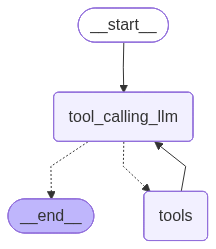

In [37]:
##StateGraph

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver


## Node defination

def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

##Graph
builder =StateGraph(State)
builder.add_node('tool_calling_llm',tool_calling_llm)
builder.add_node('tools',ToolNode(tools))
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm',
    #if the latest message from assistant then call->tools conditon route
    tools_condition,
    
)
builder.add_edge('tools', "tool_calling_llm")

memory = MemorySaver()
graph =builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
config={"configurable": {"thread_id": "user_1"}}

In [39]:
result = graph.invoke({"messages": [{"role": "user", "content": " What is my name?"}]},config)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

 What is my name?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and we haven't discussed anything personal yet. If you'd like to share your name, I'd be happy to chat with you!


In [40]:
result = graph.invoke({"messages": [{"role": "user", "content": " My name is Kishore"}]},config)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

 What is my name?
================================== Ai Message ==================================

I don't have any information about your name. This conversation just started, and we haven't discussed anything personal yet. If you'd like to share your name, I'd be happy to chat with you!
================================ Human Message =================================

 My name is Kishore
================================== Ai Message ==================================

Hello Kishore! It's nice to meet you. Is there something I can help you with or would you like to chat?


In [41]:
result = graph.invoke({"messages": [{"role": "user", "content": " What is my name?"}]},config)
# for m in result["messages"]:
#     m.pretty_print()
print(result["messages"][-1].content)

Your name is Kishore. We established that earlier in our conversation.


In [42]:
result = graph.invoke({"messages": [{"role": "user", "content": " Do you remember me?"}]},config)
# for m in result["messages"]:
#     m.pretty_print()
print(result["messages"][-1].content)

I remember that your name is Kishore, but I'm a large language model, I don't have personal memories or the ability to recall individual users. Each time you interact with me, it's a new conversation. However, within the context of this conversation, I can recall the information you've shared with me so far, such as your name.


# Streaming in LangGraph

Streaming is a core feature of **LangGraph** that enables applications to receive updates **in real time** while a graph is executing. Instead of waiting for the entire workflow to finish, developers can stream intermediate outputs such as LLM tokens, state updates, tool execution results, and custom events. This improves responsiveness and provides better visibility into how an AI agent is reasoning and progressing through a task.

## Why Streaming?

Without streaming, users must wait until the entire graph execution completes before receiving a response. With streaming enabled, the application can display partial results immediately, creating a more interactive and responsive user experience.

## How Streaming Works

During graph execution, LangGraph emits events whenever a node executes or the graph state changes. The client receives these events sequentially and can update the user interface in real time.

```text
          User Request
                │
                ▼
        ┌────────────────┐
        │  Agent Graph   │
        └───────┬────────┘
                │
        ┌───────┴────────┐
        ▼                ▼
    LLM Node         Tool Node
        │                │
        └───────┬────────┘
                ▼
         Stream Events
                │
                ▼
      Client / Terminal / UI
```

## Streaming Modes

LangGraph supports multiple streaming modes:

- **values** – Streams the complete graph state after each node execution.
- **updates** – Streams only the changes made to the state.
- **messages** – Streams LLM tokens and generated messages in real time.
- **custom** – Streams developer-defined events from within graph nodes.
- **debug** – Streams detailed execution information for debugging and development.

## Benefits

- Real-time AI responses
- Better user experience
- Live visualization of workflow execution
- Easier debugging of complex agent workflows
- Monitoring tool execution and state transitions
- Faster perceived response times

## Common Use Cases

- AI chatbots
- Coding assistants
- Customer support agents
- Multi-agent workflows
- Long-running automation tasks
- Research assistants
- Document processing pipelines

## Streaming in LangGraph

Streaming is performed using methods such as `graph.stream()` or `graph.astream()`. As each node executes, LangGraph emits events that can be consumed by applications, web interfaces, or command-line tools to display incremental progress instead of waiting for the final result.

## Best Practices

- Use **messages** mode for chat applications to stream LLM tokens.
- Use **updates** mode to monitor state changes efficiently.
- Use **values** mode when the complete graph state is required after each step.
- Use **debug** mode during development to trace execution.
- Use asynchronous streaming (`astream`) for web servers and production applications.

## Conclusion

Streaming is an essential capability in LangGraph for building responsive, production-ready AI agents. By delivering incremental updates during graph execution, it improves user experience, simplifies debugging, and provides real-time visibility into reasoning, tool execution, and workflow progress, making complex agentic applications more interactive and transparent.

In [43]:
from langgraph.checkpoint.memory import MemorySaver
memory =MemorySaver()

In [44]:
def superbot(state: State):
    return{"messages":[model.invoke(state["messages"])]}

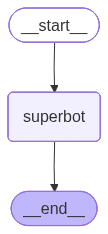

In [45]:
graph= StateGraph(State)

graph.add_node("superbot", superbot)
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)
graph_builder = graph.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [46]:
config={"configurable": {"thread_id": "thread_1"}}
result = graph_builder.invoke({"messages": [{"role": "user", "content": " Hi i am Kishor I love coding and i love watching Movies ?"}]}, config)
result

{'messages': [HumanMessage(content=' Hi i am Kishor I love coding and i love watching Movies ?', additional_kwargs={}, response_metadata={}, id='e0b7b44c-6c9f-4998-b3ee-9092ccebf55e'),
  AIMessage(content="Hi Kishor, nice to meet you. It's great to hear that you're passionate about coding and watching movies. Coding can be a fascinating field, and there are always new things to learn and discover. And movies can be a wonderful way to relax and escape into different worlds and stories.\n\nWhat kind of coding do you enjoy doing? Are you more into web development, mobile app development, or something else? And what kind of movies do you like watching? Are you a fan of action, comedy, sci-fi, or something else?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 50, 'total_tokens': 161, 'completion_time': 0.31133817, 'completion_tokens_details': None, 'prompt_time': 0.002429167, 'prompt_tokens_details': None, 'queue_time': 0.166144121, 'tot

In [47]:
config={"configurable": {"thread_id": "thread_2"}}
for chunk in graph_builder.stream({"messages": [{"role": "user", "content": " Hi i am Kishor I love coding and i love watching Movies ?"}]}, config,stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content=' Hi i am Kishor I love coding and i love watching Movies ?', additional_kwargs={}, response_metadata={}, id='179c6cd5-e23e-4bad-83d4-1ae747574692')]}
{'messages': [HumanMessage(content=' Hi i am Kishor I love coding and i love watching Movies ?', additional_kwargs={}, response_metadata={}, id='179c6cd5-e23e-4bad-83d4-1ae747574692'), AIMessage(content="Hi Kishor, nice to meet you. It's great to hear that you're passionate about coding and watching movies. Coding can be a fascinating field, and there are always new things to learn and discover. And movies can be a wonderful way to relax and escape into different worlds and stories.\n\nWhat kind of coding do you enjoy doing? Are you more into web development, mobile app development, or something else? And what kind of movies do you like watching? Are you a fan of action, comedy, sci-fi, or something else?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens

In [48]:
config={"configurable": {"thread_id": "thread_2"}}
for chunk in graph_builder.stream({"messages": [{"role": "user", "content": " Hi i am Kishor I love coding and i love watching Movies ?"}]}, config,stream_mode="updates"):
    print(chunk)


{'superbot': {'messages': [AIMessage(content="Hi Kishor, nice to meet you again. It seems like you're excited to share your interests with me. Coding and watching movies can be a great combination - coding can be a creative outlet, and movies can be a fun way to unwind and get inspired.\n\nSo, what's your favorite thing to code? Are you working on any exciting projects right now? And what kind of movies have you been enjoying lately? Have you seen any new releases that you'd recommend?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 185, 'total_tokens': 282, 'completion_time': 0.322447842, 'completion_tokens_details': None, 'prompt_time': 0.009378128, 'prompt_tokens_details': None, 'queue_time': 0.161479439, 'total_time': 0.33182597}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f64de-68

In [49]:

for chunk in graph_builder.stream({"messages": [{"role": "user", "content": " I also Live in Florida ?"}]}, config,stream_mode="values"):
    print(chunk)


{'messages': [HumanMessage(content=' Hi i am Kishor I love coding and i love watching Movies ?', additional_kwargs={}, response_metadata={}, id='179c6cd5-e23e-4bad-83d4-1ae747574692'), AIMessage(content="Hi Kishor, nice to meet you. It's great to hear that you're passionate about coding and watching movies. Coding can be a fascinating field, and there are always new things to learn and discover. And movies can be a wonderful way to relax and escape into different worlds and stories.\n\nWhat kind of coding do you enjoy doing? Are you more into web development, mobile app development, or something else? And what kind of movies do you like watching? Are you a fan of action, comedy, sci-fi, or something else?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 50, 'total_tokens': 161, 'completion_time': 0.294458128, 'completion_tokens_details': None, 'prompt_time': 0.002210271, 'prompt_tokens_details': None, 'queue_time': 0.163295557, 'tota

In [ ]:
config={"configurable": {"thread_id": "thread_4"}}

async for chunk in graph_builder.astream_events({"messages": [{"role": "user", "content": " Hi i am Kishor I love coding and i love watching Movies ?"}]}, config,version="v1"):
    print(chunk)


{'event': 'on_chain_start', 'run_id': '019f64de-7917-7481-a5ce-5b3aa82ec9c7', 'name': 'LangGraph', 'tags': [], 'metadata': {}, 'data': {'input': {'messages': [{'role': 'user', 'content': ' Hi i am Kishor I love coding and i love watching Movies ?'}]}}, 'parent_ids': []}
{'event': 'on_chain_start', 'name': 'superbot', 'run_id': '019f64de-791a-76c1-a540-8d2b165bf304', 'tags': ['graph:step:1'], 'metadata': {'thread_id': 'thread_4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:c1741920-97c4-f381-77f5-a698f2975635'}, 'data': {'input': {'messages': [HumanMessage(content=' Hi i am Kishor I love coding and i love watching Movies ?', additional_kwargs={}, response_metadata={}, id='a0adefd2-5aa4-48b0-8bed-3e179083a4b3')]}}, 'parent_ids': []}
{'event': 'on_chat_model_start', 'name': 'ChatGroq', 'run_id': '019f64de-791b-72b1-9733-

c:\Users\kisho\WorkSpace\learning\ai workflow\langchain\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3746: LangChainDeprecationWarning: astream_events version='v1' is deprecated. Use version='v2' or astream instead.
  await eval(code_obj, self.user_global_ns, self.user_ns)
